# Laboratorium 8: Modele oświetlenia


### Opis programów:

W skrócie, każdy program:

- rysuje trójkąt(y) na obrazie ignorując ich pozycje Z (rzut równoległy na OXY) za pomocą linii i funkcji floodfill.
- wylicza wektor normalny dla trójkata(ów).
- oblicza jasność KAŻDEGO pixela na obrazie w pętli sprawdzającej każdy pixel po kolei.
  - jesli pixel jest tłem (kolor czarny), to jest ignorowany.
  - w przeciwnym przypakdu dane trójkąta są przekazywane do funkcji oświetlenia, która oblicza jasność i zwraca kolor, który jest przypisywany do danego pixela.

### Zadanie 3 i problem wielu trójkątów:

kod był pisany z myślą o jednym trójkącie. Aby obsłużyć wiele trójkątów każdy z nich malowany jest na ten sam kolor ale na innych kanałach. Dzięki takiemu działaniu trójkąty mają ten sam kolor (obraz jest szary), ale w pętli dla każdego pixela w obrazie możemy sprawdzić który trójkąt jest aktualnie renderowany za pomocą sprawdzenia koloru. Wtedy przekazujemy do funkcji oświetlenia odpowiednie normalne i współrzędne wierzchołków. W ten sposób możemy renderować wiele trójkątów, a każdy z nich będzie miał swoje oświetlenie.


In [ ]:
import numpy as np
import sys

sys.setrecursionlimit(100000)


def floodfill(Image, x, y, newColor):
    imgCopy = Image.copy()

    def floodfill_inplace(Image, x, y, newColor):
        oldColor = Image[y][x].copy()
        if (oldColor == newColor).all():
            return
        Image[y][x] = newColor
        if x > 0 and (Image[y][x - 1] == oldColor).all():
            floodfill_inplace(Image, x - 1, y, newColor)
        if x < len(Image[0]) - 1 and (Image[y][x + 1] == oldColor).all():
            floodfill_inplace(Image, x + 1, y, newColor)
        if y > 0 and (Image[y - 1][x] == oldColor).all():
            floodfill_inplace(Image, x, y - 1, newColor)
        if y < len(Image) - 1 and (Image[y + 1][x] == oldColor).all():
            floodfill_inplace(Image, x, y + 1, newColor)

    floodfill_inplace(imgCopy, x, y, newColor)
    return imgCopy


def linia1(Im1, yp, xp, yk, xk, C):
    """
    Im1 - input image
    (yp, xp) - starting point of the line
    (yk, xk) - ending point of the line
    C - color of the line
    """
    Y, X, _ = Im1.shape
    Im2 = Im1.copy()

    if abs(yk - yp) > abs(xk - xp):
        x0, y0, x1, y1 = yp, xp, yk, xk
        zamiana = 1
    else:
        x0, y0, x1, y1 = xp, yp, xk, yk
        zamiana = 0

    if zamiana == 1:
        X, Y = Y, X

    if x0 > x1:
        x0, x1 = x1, x0
        y0, y1 = y1, y0

    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sy = 1 if y1 > y0 else (-1 if y1 < y0 else 0)

    x, y = x0, y0

    def draw_point(px, py):
        if 0 <= px < X and 0 <= py < Y:
            if zamiana == 0:
                Im2[py, px] = C
            else:
                Im2[px, py] = C

    draw_point(x, y)

    error = 2 * dy - dx
    for _ in range(dx):
        error += 2 * dy
        if error > 0:
            y += sy
            error -= 2 * dx
        x += 1
        draw_point(x, y)

    return Im2


def mat2pix(m, n, dx, dy, x, y):
    """
    m, n - size of the image in pixels
    dx, dy - size of the image in math coordinates
    x, y - math coordinates of the point
    """
    transformMatrix = np.array([[1 / dx, 0, 0.5 * m], [0, -1 / dy, 0.5 * n], [0, 0, 1]])

    pixelCoords = np.dot(transformMatrix, np.array([x, y, 1]))
    return round(pixelCoords[0] / pixelCoords[2], 0), round(
        pixelCoords[1] / pixelCoords[2], 0
    )


def pix2mat(m, n, dx, dy, u, v):
    transformMatrix = np.array(
        [[dx, 0, -0.5 * m * dx], [0, -dy, 0.5 * n * dy], [0, 0, 1]]
    )

    mathCords = np.dot(transformMatrix, np.array([u, v, 1]))
    return (mathCords[0] / mathCords[2]), (mathCords[1] / mathCords[2])


def Persp(f):
    H = np.zeros((4, 4), dtype=float)
    H[0, 0] = 1.0
    H[1, 1] = 1.0
    H[3, 2] = -1.0 / f
    H[3, 3] = 1.0
    return H


def plane(p1, p2, p3):
    """
    Wyznacza równanie płaszczyzny przechodzącej przez trzy punkty 3D.

    Argumenty:
    p1, p2, p3 : array-like o długości 3
        Punkty 3D w postaci [x, y, z].

    Zwraca:
    tuple[float, float, float, float]
        Współczynniki (A, b, c, d) równania płaszczyzny:
        A*x + b*y + c*z + d = 0.

    Wyjątki:
    ValueError
        Gdy punkty są współliniowe i nie wyznaczają jednoznacznej płaszczyzny.
    """
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    p3 = np.asarray(p3, dtype=float)

    v1 = p2 - p1
    v2 = p3 - p1
    normal = np.cross(v1, v2)

    if np.allclose(normal, 0.0):
        raise ValueError("Punkty są współliniowe - nie wyznaczają płaszczyzny.")

    A, b, c = normal
    d = -np.dot(normal, p1)
    return float(A), float(b), float(c), float(d)


def normal_vector(p1, p2, p3):
    """
    Wyznacza wektor normalny płaszczyzny określonej przez trzy punkty 3D.

    Argumenty:
    p1, p2, p3 : array-like o długości 3
        Punkty 3D w postaci [x, y, z].

    Zwraca:
    tuple[float, float, float]
        Składowe wektora normalnego (nx, ny, nz).

    Wyjątki:
    ValueError
        Gdy punkty są współliniowe i nie wyznaczają jednoznacznej płaszczyzny.
    """
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    p3 = np.asarray(p3, dtype=float)

    v1 = p2 - p1
    v2 = p3 - p1
    normal = np.cross(v2, v1)

    if np.allclose(normal, 0.0):
        raise ValueError("Punkty są współliniowe - nie wyznaczają płaszczyzny.")

    return float(normal[0]), float(normal[1]), float(normal[2])


def distance2plane(point, A, b, c, d):
    """
    Oblicza odległość punktu 3D od płaszczyzny oraz wyznacza punkt na płaszczyźnie,
    który jest rzutem prostopadłym danego punktu.

    Argumenty:
    point : array-like o długości 3
        Punkt 3D w postaci [x, y, z].
    A, b, c, d : float
        Współczynniki równania płaszczyzny:
        A*x + b*y + c*z + d = 0.

    Zwraca:
    tuple[float, np.ndarray]
        - float: Nieujemna odległość punktu od płaszczyzny.
        - np.ndarray: Punkt 3D na płaszczyźnie (rzut prostopadły danego punktu).

    Wyjątki:
    ValueError
        Gdy wektor normalny płaszczyzny ma długość zero.
    """
    point = np.asarray(point, dtype=float)
    x, y, z = point

    mianownik = A**2 + b**2 + c**2

    if np.isclose(mianownik, 0.0):
        raise ValueError(
            "Nieprawidłowa płaszczyzna: A, b, c nie mogą być jednocześnie zerowe."
        )

    licznik = A * x + b * y + c * z + d

    # Parametr t dla punktu na płaszczyźnie (rzut prostopadły)
    t = -licznik / mianownik

    # Współrzędne punktu na płaszczyźnie
    x_plane = x + t * A
    y_plane = y + t * b
    z_plane = z + t * c
    plane_point = np.array([x_plane, y_plane, z_plane])

    # Odległość
    distance = np.abs(licznik) / np.sqrt(mianownik)

    return float(distance), plane_point


def lambert_intensity(
    ambient_intensity=0,
    lights=[],
    x=0,
    y=0,
    z=0,
    normalVector=(0, 0, 1),
    epsilon=1,
    alfa=0.001,
):
    """
    Oblicza natężenie światła padającego na punkt 3D zgodnie z modelem oświetlenia Lamberta.

    Argumenty:
    ambient_intensity : float
        Natężenie światła otoczenia (ambient light).
    lights : list of tuples
        Lista źródeł światła, gdzie każde źródło jest reprezentowane jako krotka (intensity, (lx, ly, lz)).
    x, y, z : float
        Współrzędne punktu 3D, dla którego obliczamy natężenie.
    normalVector : tuple of floats
        Wektor normalny do powierzchni w punkcie (nx, ny, nz).
    epsilon : float
        Mała wartość dodawana do mianownika, aby uniknąć dzielenia przez zero.

    Zwraca:
    float
        Obliczone natężenie światła padającego na punkt 3D.
    """
    nx, ny, nz = normalVector
    normal_length = np.sqrt(nx**2 + ny**2 + nz**2)

    total_intensity = ambient_intensity

    for intensity, (lx, ly, lz) in lights:
        # wektor od punktu do źródła światła
        light_vector = np.array([lx - x, ly - y, lz - z])
        light_length = np.linalg.norm(light_vector)

        # Jeśli źródło światła jest dokładnie w punkcie, pomijamy je, ponieważ nie ma kierunku światła.
        if np.isclose(light_length, 0.0):
            continue

        light_vector_normalized = light_vector / light_length
        normal_normalized = np.array([nx, ny, nz]) / normal_length

        # kąt między wektorem światła a wektorem normalnym tak jak na wykładzie
        angle_from_light_to_normal = np.dot(normal_normalized, light_vector_normalized)

        total_intensity += (
            epsilon
            * intensity
            / (1 + alfa * light_length**2)
            * max(angle_from_light_to_normal, 0)
        )

    return total_intensity


def phong_intensity(
    ambient_intensity=0,
    lights=[],
    x=0,
    y=0,
    z=0,
    normalVector=(0, 0, 1),
    eye_pos=(0, 0, 0),
    epsilon=1,
    alfa=0.001,
    m=5,
):

    nx, ny, nz = normalVector
    normal_length = np.sqrt(nx**2 + ny**2 + nz**2)

    total_intensity = ambient_intensity

    # Znormalizowany wektor do obserwatora
    eye_vector = np.array([eye_pos[0] - x, eye_pos[1] - y, eye_pos[2] - z])
    eye_length = np.linalg.norm(eye_vector)

    if np.isclose(eye_length, 0.0):
        eye_vector_normalized = np.array([0, 0, 1])
    else:
        eye_vector_normalized = eye_vector / eye_length

    normal_normalized = np.array([nx, ny, nz]) / normal_length

    for intensity, (lx, ly, lz) in lights:
        light_vector = np.array([lx - x, ly - y, lz - z])
        light_length = np.linalg.norm(light_vector)

        if np.isclose(light_length, 0.0):
            continue

        light_vector_normalized = light_vector / light_length

        # Składowa rozproszona (Lamberta)
        diffuse_dot = np.dot(normal_normalized, light_vector_normalized)
        diffuse_contribution = (
            epsilon * intensity / (1 + alfa * light_length**2) * max(diffuse_dot, 0)
        )

        # Składowa lustrzana (Specular)
        # Wektor odbicia: R = 2(N·L)N - L
        reflection_vector = (
            2 * diffuse_dot * normal_normalized - light_vector_normalized
        )

        # Cosinus kąta między wektorem odbicia a wektorem do obserwatora
        specular_dot = np.dot(reflection_vector, eye_vector_normalized)
        specular_contribution = (
            intensity / (1 + alfa * light_length**2) * (max(specular_dot, 0) ** m)
        )

        total_intensity += diffuse_contribution + specular_contribution

    return total_intensity


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

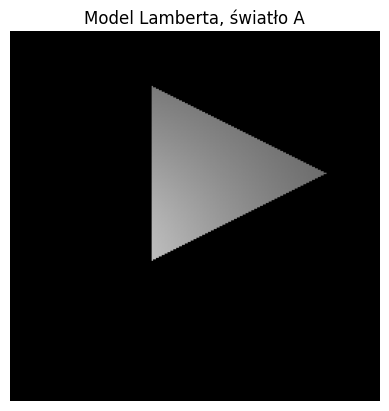

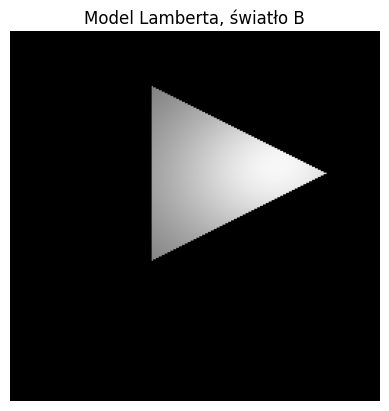

In [63]:
import numpy as np
import matplotlib.pyplot as plt

T1 = np.array([[9, 3, 16], [-3, 9, 6], [-3, -3, 4]], dtype=np.float32)
T1_epsilon = 1
alfa = 0.001

rozdzielczosc_x = 256
rozdzielczosc_y = 256

AmbientLightIntensity = 20

Lights_A = [(235, np.array([-3, -3, -10], dtype=np.float32))]
Lights_B = [(235, np.array([3, 3, 3], dtype=np.float32))]

image = np.zeros((rozdzielczosc_x, rozdzielczosc_y, 3), dtype=np.uint8)

T1_11, T1_12 = mat2pix(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, T1[0, 0], T1[0, 1])
T1_21, T1_22 = mat2pix(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, T1[1, 0], T1[1, 1])
T1_31, T1_32 = mat2pix(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, T1[2, 0], T1[2, 1])

image = linia1(image, int(T1_12), int(T1_11), int(T1_22), int(T1_21), (255, 255, 255))
image = linia1(image, int(T1_22), int(T1_21), int(T1_32), int(T1_31), (255, 255, 255))
image = linia1(image, int(T1_32), int(T1_31), int(T1_12), int(T1_11), (255, 255, 255))
image = floodfill(
    image,
    int(round((T1_11 + T1_21 + T1_31) / 3 + 1)),
    int(round((T1_12 + T1_22 + T1_32) / 3 + 1)),
    (255, 255, 255),
)

# compute plane coefficients for the triangle so we can get correct z at each pixel
A, b, c, d = plane(T1[0], T1[1], T1[2])

normal = normal_vector(T1[0], T1[1], T1[2])

for i in range(rozdzielczosc_x):
    for j in range(rozdzielczosc_y):
        x, y = pix2mat(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, j, i)
        plane_distance, plane_point = distance2plane((x, y, 0), A, b, c, d)
        # jeżeli pixel nie jest biały to znaczy że jest tłem i nie trzeba go kolorować
        if (image[i, j] == [0, 0, 0]).all():
            continue

        intensity = lambert_intensity(
            ambient_intensity=AmbientLightIntensity,
            lights=Lights_A,
            x=plane_point[0],
            y=plane_point[1],
            z=plane_point[2],
            normalVector=normal,
            epsilon=T1_epsilon,
            alfa=alfa,
        )
        gray = np.uint8(np.clip(intensity, 0, 255))
        image[i, j] = (gray, gray, gray)

plt.imshow(image, cmap="gray")
plt.title("Model Lamberta, światło A")
plt.axis("off")


image = np.zeros((rozdzielczosc_x, rozdzielczosc_y, 3), dtype=np.uint8)
image = linia1(image, int(T1_12), int(T1_11), int(T1_22), int(T1_21), (255, 255, 255))
image = linia1(image, int(T1_22), int(T1_21), int(T1_32), int(T1_31), (255, 255, 255))
image = linia1(image, int(T1_32), int(T1_31), int(T1_12), int(T1_11), (255, 255, 255))
image = floodfill(
    image,
    int(round((T1_11 + T1_21 + T1_31) / 3 + 1)),
    int(round((T1_12 + T1_22 + T1_32) / 3 + 1)),
    (255, 255, 255),
)

for i in range(rozdzielczosc_x):
    for j in range(rozdzielczosc_y):
        x, y = pix2mat(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, j, i)
        plane_distance, plane_point = distance2plane((x, y, 0), A, b, c, d)

        # jeżeli pixel nie jest biały to znaczy że jest tłem i nie trzeba go kolorować
        if (image[i, j] == [0, 0, 0]).all():
            continue
        intensity = lambert_intensity(
            ambient_intensity=AmbientLightIntensity,
            lights=Lights_B,
            x=plane_point[0],
            y=plane_point[1],
            z=plane_point[2],
            normalVector=normal_vector(T1[0], T1[1], T1[2]),
            epsilon=T1_epsilon,
            alfa=alfa,
        )
        gray = np.uint8(np.clip(intensity, 0, 255))
        image[i, j] = (gray, gray, gray)

plt.figure()
plt.imshow(image, cmap="gray")
plt.title("Model Lamberta, światło B")
plt.axis("off")


# Zadanie 2: Model Phonga

Model Phonga = oświetlenie modelu Lamberta + oświetlenie modelu Phonga

Obserwator (oko) w punkcie: (5, 5, 3)
Różne wartości potęgi m dla wyrażenia (R·V)^m


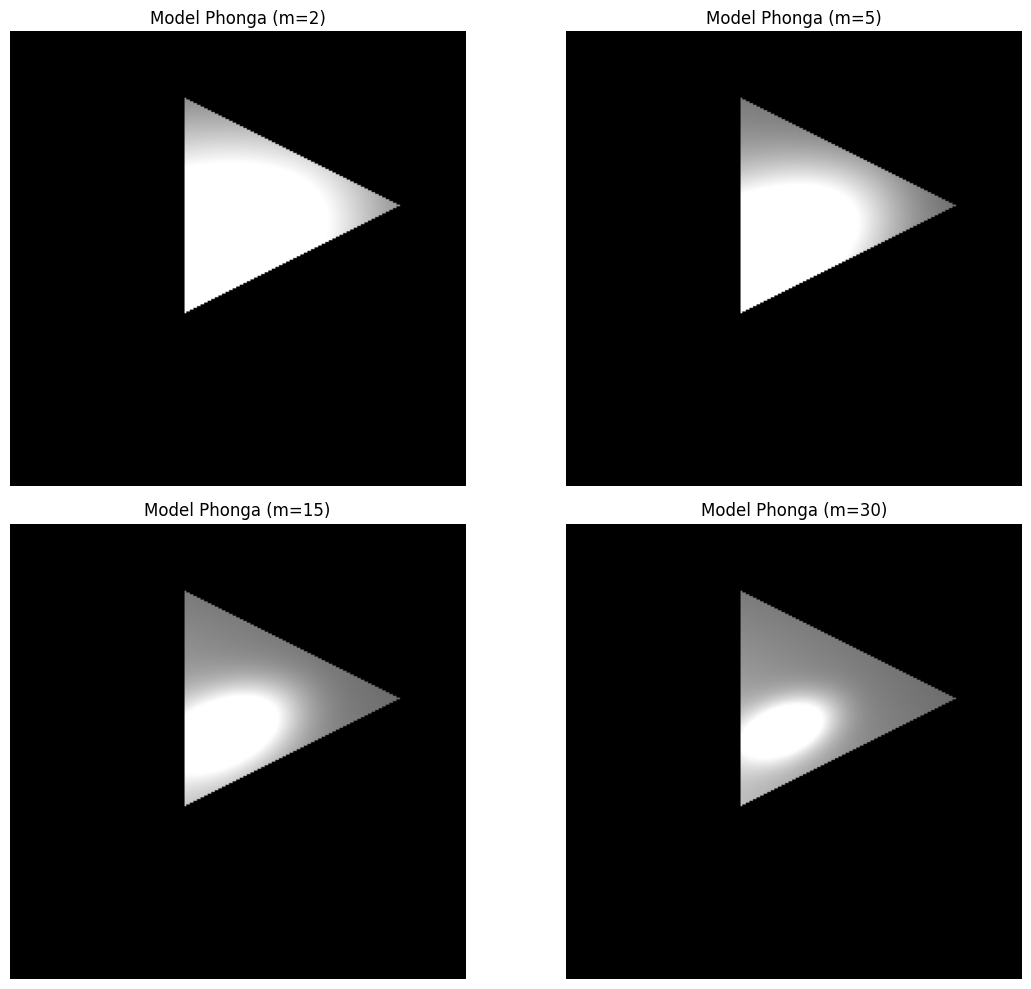

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Parametry
T1 = np.array([[9, 3, 16], [-3, 9, 6], [-3, -3, 4]], dtype=np.float32)
T1_epsilon = 1
alfa = 0.001
eye_position = (5, 5, 3)

rozdzielczosc_x = 256
rozdzielczosc_y = 256

AmbientLightIntensity = 20
Lights_A = [(235, np.array([-3, -3, -10], dtype=np.float32))]

# Różne wartości potęgi specular exponent
m_values = [2, 5, 15, 30]

# compute plane coefficients for the triangle
A, b, c, d = plane(T1[0], T1[1], T1[2])
normal = normal_vector(T1[0], T1[1], T1[2])

# Przygotuj pixel coordinates dla rysowania trójkąta
T1_11, T1_12 = mat2pix(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, T1[0, 0], T1[0, 1])
T1_21, T1_22 = mat2pix(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, T1[1, 0], T1[1, 1])
T1_31, T1_32 = mat2pix(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, T1[2, 0], T1[2, 1])

# Utwórz subploty dla różnych wartości m
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, m in enumerate(m_values):
    # Utwórz obraz
    image = np.zeros((rozdzielczosc_x, rozdzielczosc_y, 3), dtype=np.uint8)

    # Narysuj trójkąt
    image = linia1(
        image, int(T1_12), int(T1_11), int(T1_22), int(T1_21), (255, 255, 255)
    )
    image = linia1(
        image, int(T1_22), int(T1_21), int(T1_32), int(T1_31), (255, 255, 255)
    )
    image = linia1(
        image, int(T1_32), int(T1_31), int(T1_12), int(T1_11), (255, 255, 255)
    )
    image = floodfill(
        image,
        int(round((T1_11 + T1_21 + T1_31) / 3 + 1)),
        int(round((T1_12 + T1_22 + T1_32) / 3 + 1)),
        (255, 255, 255),
    )

    # Oblicz oświetlenie dla każdego pixela
    for i in range(rozdzielczosc_x):
        for j in range(rozdzielczosc_y):
            x, y = pix2mat(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, j, i)
            plane_distance, plane_point = distance2plane((x, y, 0), A, b, c, d)

            # Jeżeli pixel nie jest biały to znaczy że jest tłem
            if (image[i, j] == [0, 0, 0]).all():
                continue

            # Oblicz intensywność modelem Phonga
            intensity = phong_intensity(
                ambient_intensity=AmbientLightIntensity,
                lights=Lights_A,
                x=plane_point[0],
                y=plane_point[1],
                z=plane_point[2],
                normalVector=normal,
                eye_pos=eye_position,
                epsilon=T1_epsilon,
                alfa=alfa,
                m=m,
            )

            gray = np.uint8(np.clip(intensity, 0, 255))
            image[i, j] = (gray, gray, gray)

    # Wyświetl obraz
    axes[idx].imshow(image, cmap="gray")
    axes[idx].set_title(f"Model Phonga (m={m})")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


# Zadanie 3

Model oświetlenia Lamberta i Phonga dla świateł z zadań 1 i 2 gdy zamiast jednego trójkąta dane są dwa trójkąty przylegające do siebie jednym bokiem:
[9,3,16],[-3,9,6],[-3,-3,4] oraz
[9,3,16],[-3,-3,4],[9,-6,5]


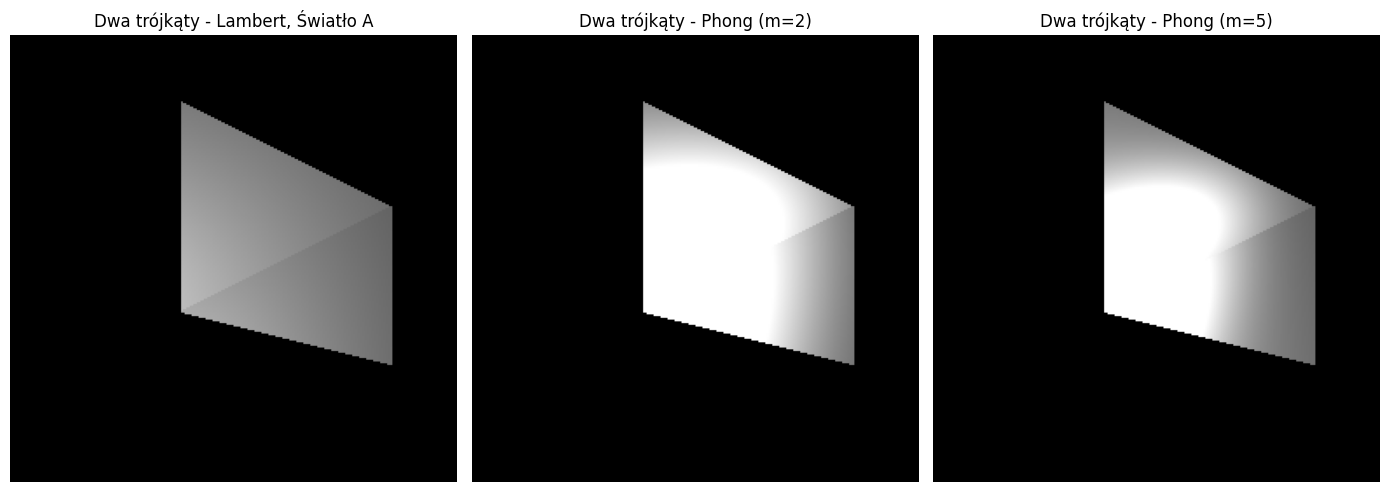

In [65]:
import numpy as np
import matplotlib.pyplot as plt

T1 = np.array([[9, 3, 16], [-3, 9, 6], [-3, -3, 4]], dtype=np.float32)
T2 = np.array([[9, 3, 16], [-3, -3, 4], [9, -6, 5]], dtype=np.float32)

T1_epsilon = 1
alfa = 0.001
eye_position = (5, 5, 3)

rozdzielczosc_x = 256
rozdzielczosc_y = 256

AmbientLightIntensity = 20
Lights_A = [(235, np.array([-3, -3, -10], dtype=np.float32))]
Lights_B = [(235, np.array([3, 3, 3], dtype=np.float32))]

A1, b1, c1, d1 = plane(T1[0], T1[1], T1[2])
normal1 = normal_vector(T1[0], T1[1], T1[2])

A2, b2, c2, d2 = plane(T2[0], T2[1], T2[2])
normal2 = normal_vector(T2[0], T2[1], T2[2])

T1_11, T1_12 = mat2pix(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, T1[0, 0], T1[0, 1])
T1_21, T1_22 = mat2pix(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, T1[1, 0], T1[1, 1])
T1_31, T1_32 = mat2pix(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, T1[2, 0], T1[2, 1])

T2_11, T2_12 = mat2pix(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, T2[0, 0], T2[0, 1])
T2_21, T2_22 = mat2pix(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, T2[1, 0], T2[1, 1])
T2_31, T2_32 = mat2pix(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, T2[2, 0], T2[2, 1])

# LABMERT - ŚWIATŁO A
image = np.zeros((rozdzielczosc_x, rozdzielczosc_y, 3), dtype=np.uint8)

image = linia1(image, int(T1_12), int(T1_11), int(T1_22), int(T1_21), (200, 0, 0))
image = linia1(image, int(T1_22), int(T1_21), int(T1_32), int(T1_31), (200, 0, 0))
image = linia1(image, int(T1_32), int(T1_31), int(T1_12), int(T1_11), (200, 0, 0))

image = linia1(image, int(T2_12), int(T2_11), int(T2_22), int(T2_21), (0, 0, 200))
image = linia1(image, int(T2_22), int(T2_21), int(T2_32), int(T2_31), (0, 0, 200))
image = linia1(image, int(T2_32), int(T2_31), int(T2_12), int(T2_11), (0, 0, 200))

# Zamaluj wnętrze tym samym kolorem co krawędzie
image = floodfill(
    image,
    int(round((T1_11 + T1_21 + T1_31) / 3)),
    int(round((T1_12 + T1_22 + T1_32) / 3)),
    (200, 0, 0),
)

image = floodfill(
    image,
    int(round((T2_11 + T2_21 + T2_31) / 3)),
    int(round((T2_12 + T2_22 + T2_32) / 3)),
    (0, 0, 200),
)

for i in range(rozdzielczosc_x):
    for j in range(rozdzielczosc_y):
        x, y = pix2mat(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, j, i)

        if np.array_equal(image[i, j], [200, 0, 0]):  # Trójkąt 1
            plane_distance, plane_point = distance2plane((x, y, 0), A1, b1, c1, d1)
            intensity = lambert_intensity(
                ambient_intensity=AmbientLightIntensity,
                lights=Lights_A,
                x=plane_point[0],
                y=plane_point[1],
                z=plane_point[2],
                normalVector=normal1,
                epsilon=T1_epsilon,
                alfa=alfa,
            )
        elif np.array_equal(image[i, j], [0, 0, 200]):  # Trójkąt 2
            plane_distance, plane_point = distance2plane((x, y, 0), A2, b2, c2, d2)
            intensity = lambert_intensity(
                ambient_intensity=AmbientLightIntensity,
                lights=Lights_A,
                x=plane_point[0],
                y=plane_point[1],
                z=plane_point[2],
                normalVector=normal2,
                epsilon=T1_epsilon,
                alfa=alfa,
            )
        else:
            continue

        gray = np.uint8(np.clip(intensity, 0, 255))
        image[i, j] = (gray, gray, gray)

plt.figure(figsize=(14, 10))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Dwa trójkąty - Lambert, Światło A")
plt.axis("off")

# PHONG - ŚWIATŁO A
m_values = [2, 5]

for idx, m in enumerate(m_values):
    image = np.zeros((rozdzielczosc_x, rozdzielczosc_y, 3), dtype=np.uint8)

    image = linia1(image, int(T1_12), int(T1_11), int(T1_22), int(T1_21), (200, 0, 0))
    image = linia1(image, int(T1_22), int(T1_21), int(T1_32), int(T1_31), (200, 0, 0))
    image = linia1(image, int(T1_32), int(T1_31), int(T1_12), int(T1_11), (200, 0, 0))
    image = linia1(image, int(T2_12), int(T2_11), int(T2_22), int(T2_21), (0, 0, 200))
    image = linia1(image, int(T2_22), int(T2_21), int(T2_32), int(T2_31), (0, 0, 200))
    image = linia1(image, int(T2_32), int(T2_31), int(T2_12), int(T2_11), (0, 0, 200))

    image = floodfill(
        image,
        int(round((T1_11 + T1_21 + T1_31) / 3)),
        int(round((T1_12 + T1_22 + T1_32) / 3)),
        (200, 0, 0),
    )
    image = floodfill(
        image,
        int(round((T2_11 + T2_21 + T2_31) / 3)),
        int(round((T2_12 + T2_22 + T2_32) / 3)),
        (0, 0, 200),
    )

    for i in range(rozdzielczosc_x):
        for j in range(rozdzielczosc_y):
            x, y = pix2mat(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, j, i)

            if np.array_equal(image[i, j], [200, 0, 0]):  # Trójkąt 1
                plane_distance, plane_point = distance2plane((x, y, 0), A1, b1, c1, d1)
                intensity = phong_intensity(
                    ambient_intensity=AmbientLightIntensity,
                    lights=Lights_A,
                    x=plane_point[0],
                    y=plane_point[1],
                    z=plane_point[2],
                    normalVector=normal1,
                    eye_pos=eye_position,
                    epsilon=T1_epsilon,
                    alfa=alfa,
                    m=m,
                )
            elif np.array_equal(image[i, j], [0, 0, 200]):  # Trójkąt 2
                plane_distance, plane_point = distance2plane((x, y, 0), A2, b2, c2, d2)
                intensity = phong_intensity(
                    ambient_intensity=AmbientLightIntensity,
                    lights=Lights_A,
                    x=plane_point[0],
                    y=plane_point[1],
                    z=plane_point[2],
                    normalVector=normal2,
                    eye_pos=eye_position,
                    epsilon=T1_epsilon,
                    alfa=alfa,
                    m=m,
                )
            else:
                continue

            gray = np.uint8(np.clip(intensity, 0, 255))
            image[i, j] = (gray, gray, gray)

    plt.subplot(1, 3, 2 + idx)
    plt.imshow(image, cmap="gray")
    plt.title(f"Dwa trójkąty - Phong (m={m})")
    plt.axis("off")

plt.tight_layout()
plt.show()
